# Ice Online Store - Popularity of Games Sold

 - Name: Alberto Albini
 

# Libraries

In [1]:
import pandas as pd
import numpy as np 

# Understanding the data

In this step I will load the data and analyze the general information about this data.

In [2]:
df = pd.read_csv('/datasets/games.csv')
df.head()

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


## Loading data

## General Information

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


Key findings:

- Some columns the data has problems or inconsistencies (User Score, Year of Release, Rating).

- The presence of many nulls in Critic Score, User Score and Rating can affect popularity or quality analyzes.

- The absence of Year of Release in 269 games may distort time trend graphs.

# Preparing the data

Replacing column names

In [4]:
df.columns = [col.lower() for col in df.columns]

Converting the data

In [5]:
df['user_score'] = df['user_score'].replace('tbd', np.nan)
df['user_score'] = df['user_score'].astype(float)

`user score` had `tbd` values ​​(in this case values ​​yet to be defined) so these values ​​were replaced by Na N values, this way I can transform the column to `float`.

In [6]:
taxa_de_nan = df['year_of_release'].isna().sum() / df.shape[0]
print(f'Temos {taxa_de_nan:.2%} de valores nulos em "year_of_release". ')

Temos 1.61% de valores nulos em "year_of_release". 


`year of release` has only 1 61% of the values ​​NaN. So, because it is a low percentage, we can take an average and replace it with approximate values, without harming the analysis. After changing these values, I can change the column type to `int`.

In [7]:
df['year_of_release'] = df['year_of_release'].fillna(df.groupby(['name'])['year_of_release'].transform('median'))
df['year_of_release'] = df['year_of_release'].fillna(df.groupby(['platform'])['year_of_release'].transform('median'))


Converting `year of release` to `int`

In [8]:
df['year_of_release'] = df['year_of_release'].astype(int)

In [9]:
df = df.dropna(subset=['name']).reset_index(drop=True)

1. Explain your approach when filling in missing values ​​or leaving them blank.

`user score`: I replaced the 'tbd' (to be determined) values ​​with Na N, as they do not represent a valid assessment. Then, I converted the column to float, allowing to perform statistical operations.

`year of release`: as the missing values ​​represented only 1.61% of the total, I filled it in using the median at two levels:
- First, the median by game name, as it can appear on multiple platforms.
- So for those who still have zero left, I used the median by platform.
- Finally, I converted the column to int, as the release year must be an integer value.

2. In your opinion, why are the values ​​missing? Give possible reasons.

`user score`: 'tbd' values ​​indicate recently released games or games with low visibility, not yet rated by users.

`year of release`: may have been omitted due to registration failure or lack of formal/documented release.

3. Pay attention to the abbreviation TBD ("to be determined") Specify how you intend to handle these cases.

The 'tbd' values ​​found in the `user score` column were treated as missing (NaN) as they do not represent real scores.
After that, I converted the column to float type, which is essential for quantitative analysis, such as calculating averages, histograms, etc.

## Calculate total sales (the sum of sales across all regions) for each game and place these values ​​in a separate column.

In [10]:
df['total_sales'] = df['na_sales'] + df['eu_sales'] + df['jp_sales'] + df['other_sales']

In [11]:
df['total_sales']

0        82.54
1        40.24
2        35.52
3        32.77
4        31.38
         ...  
16708     0.01
16709     0.01
16710     0.01
16711     0.01
16712     0.01
Name: total_sales, Length: 16713, dtype: float64

# Analyze the data

See how many games were released each year Is the data from each period significant?

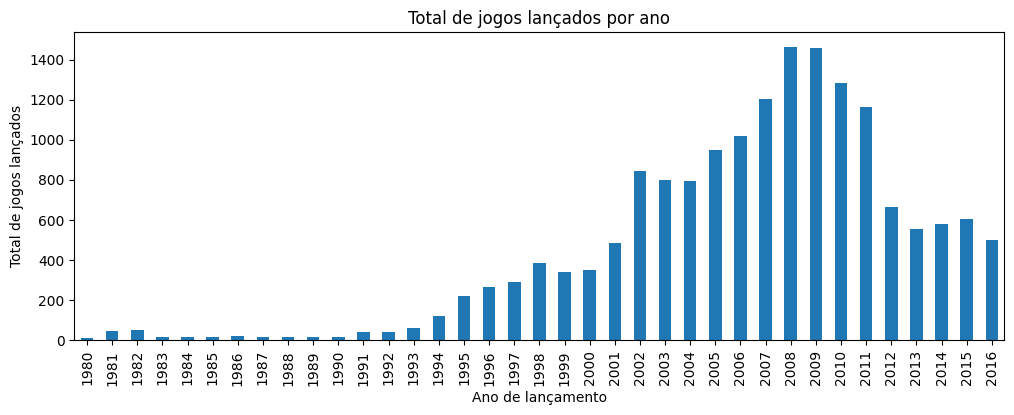

In [15]:
df.groupby('year_of_release').size().plot.bar(
    figsize = (12,4),
    title = 'Total de jogos lançados por ano',
    xlabel = 'Ano de lançamento',
    ylabel = 'Total de jogos lançados',
    
);

We can analyze through the graph that from 1991 onwards, games began to be released more frequently, with the largest number of games being released in 2008 and 2009.
From 2010 to 2016, games began to be released in a more equal and balanced way.

Identify the platforms with the highest total sales.

In [16]:
top_platforms = df.groupby('platform')['total_sales'].sum().sort_values(ascending=False)

<AxesSubplot:title={'center':'Total de Vendas por Plataforma'}, xlabel='Plataforma', ylabel='Vendas'>

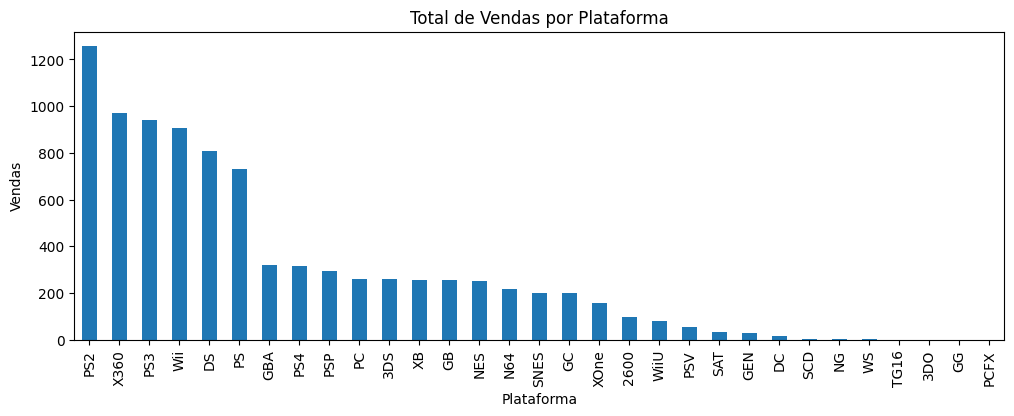

In [17]:
top_platforms.plot(
    kind='bar',
    figsize=(12,4), 
    title='Total de Vendas por Plataforma',
     xlabel = 'Plataforma',
    ylabel = 'Vendas'
    )

Build the sales distribution per year for these platforms

In [ ]:
# Creating a df with only games from the most popular platforms
df_top = df[df['platform'].isin(top_platforms.index)]

In [19]:
sales_by_year = df_top.groupby(['year_of_release', 'platform'])['total_sales'].sum().sort_values(ascending=False).head(10)

In [ ]:
#Transforming the Series into a table (Data Frame)
sales_by_year = sales_by_year.unstack(fill_value=0)

<AxesSubplot:title={'center':'Vendas Globais por Plataforma (Top 10)'}, xlabel='Ano de Lançamento', ylabel='Vendas Globais'>

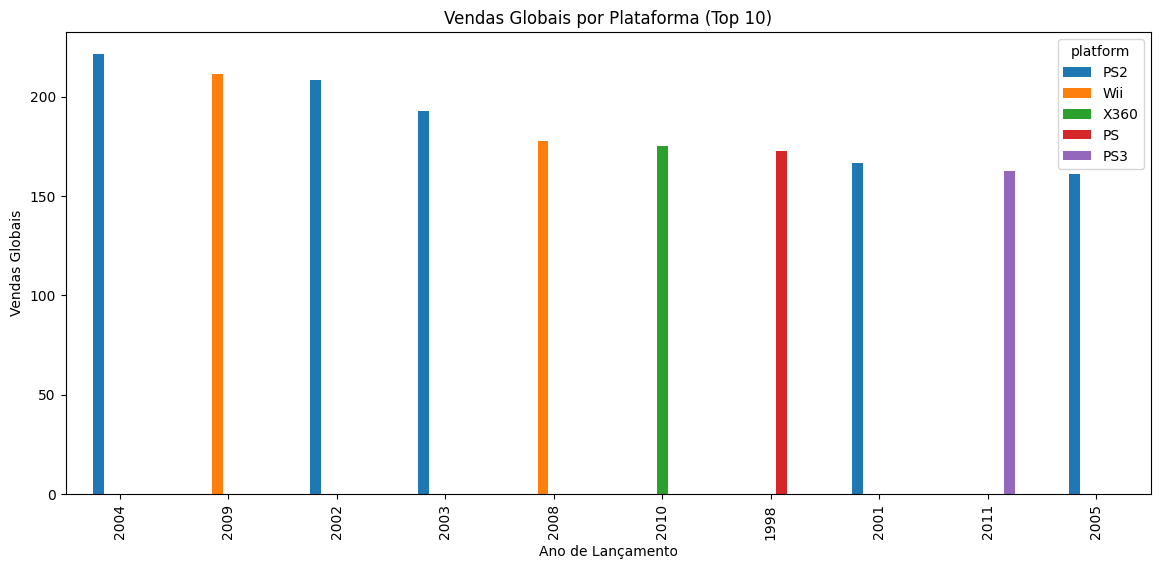

In [21]:
sales_by_year.plot(
    kind='bar',
    figsize=(14,6), 
    title='Vendas Globais por Plataforma (Top 10)',
     xlabel = 'Ano de Lançamento',
    ylabel = 'Vendas Globais'
    )

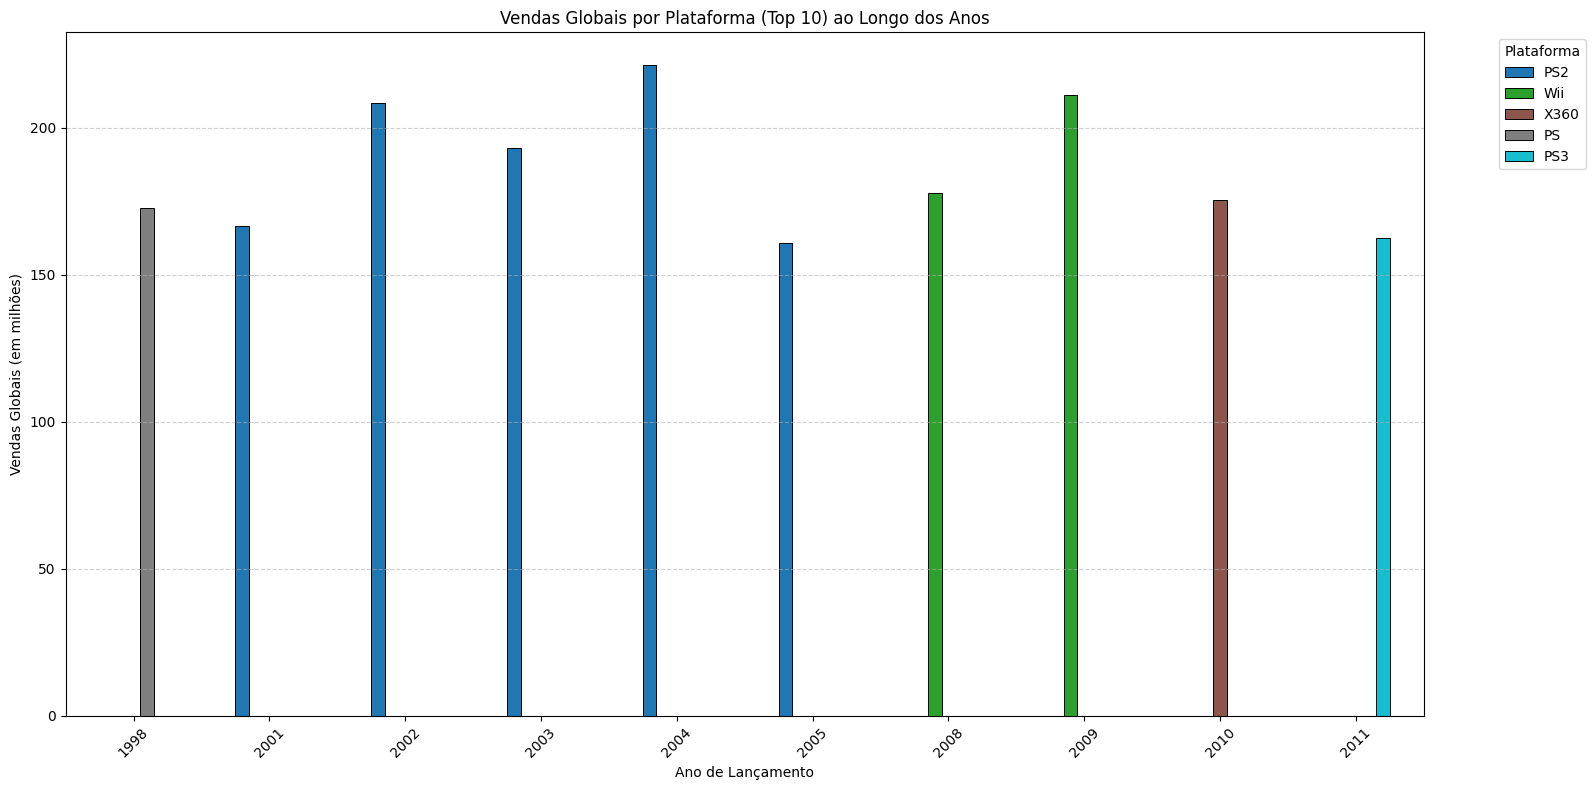

In [ ]:
import matplotlib.pyplot as plt

# Sort the Data Frame by year to ensure chronological sequence
sales_sorted = sales_by_year.sort_index()

# Create the grouped bar chart
ax = sales_sorted.plot(
    kind='bar',
    figsize=(16, 8),
    title='Vendas Globais por Plataforma (Top 10) ao Longo dos Anos',
    xlabel='Ano de Lançamento',
    ylabel='Vendas Globais (em milhões)',
    edgecolor='black',     
    linewidth=0.7,         
    colormap='tab10',      
    rot=45                 

# Add grid on y axis to make values ​​easier to read
ax.grid(axis='y', linestyle='--', alpha=0.6)

# Adjust the legend to be outside the graph and avoid overlapping
ax.legend(title='Plataforma', bbox_to_anchor=(1.05, 1), loc='upper left')

# Adjust the layout to avoid clipping
plt.tight_layout()

# Display the graph
plt.show()


Finding platforms that were once popular but now have no sales

In [20]:
sales_by_year_platform = df.groupby(['year_of_release', 'platform'])['total_sales'].sum().unstack()

In [ ]:
# Let's go through each platform (column)
for platform in sales_by_year_platform.columns:
    # Select the years in which the platform had sales > 0
    active_years = sales_by_year_platform[sales_by_year_platform[platform] > 0].index
    
    if len(active_years) > 0:
        first_year = active_years.min()
        last_year = active_years.max()
        print(f'{platform} vendeu de {first_year} até {last_year}')

2600 vendeu de 1980 até 1999
3DO vendeu de 1994 até 1995
3DS vendeu de 2000 até 2016
DC vendeu de 1998 até 2008
DS vendeu de 1985 até 2013
GB vendeu de 1988 até 2001
GBA vendeu de 2000 até 2007
GC vendeu de 2001 até 2007
GEN vendeu de 1990 até 1994
GG vendeu de 1992 até 1992
N64 vendeu de 1996 até 2004
NES vendeu de 1983 até 1994
NG vendeu de 1993 até 1996
PC vendeu de 1985 até 2016
PCFX vendeu de 1996 até 1996
PS vendeu de 1994 até 2003
PS2 vendeu de 2000 até 2011
PS3 vendeu de 2005 até 2016
PS4 vendeu de 2013 até 2016
PSP vendeu de 2004 até 2015
PSV vendeu de 2011 até 2016
SAT vendeu de 1994 até 1999
SCD vendeu de 1993 até 1994
SNES vendeu de 1990 até 1999
TG16 vendeu de 1995 até 1995
WS vendeu de 1999 até 2001
Wii vendeu de 2006 até 2016
WiiU vendeu de 2012 até 2016
X360 vendeu de 2005 até 2016
XB vendeu de 2000 até 2008
XOne vendeu de 2013 até 2016


- Platforms emerge, grow and then disappear over time, generally after about 8 to 10 years.
- Some are successful and last a long time (e.g. PS 2, DS, PC).
- Others fail and disappear quickly (e.g. GG, 3 DO).
- Until 2016, the recent leaders were PS 4, X One, 3 DS.

In [ ]:
#See the available years and how many games were released each year
games_per_year = df['year_of_release'].value_counts().sort_index()

In [ ]:
#See sales by platform by year

df['global_sales'] = (df['na_sales'] + df['eu_sales'] + df['jp_sales'] + df['other_sales'])

sales_by_year_platform = df.pivot_table(
    index='year_of_release',
    columns='platform',
    values='global_sales',
    aggfunc='sum'
)



In [24]:
#Choosing a reliable period for analysis
df_recent = df[df['year_of_release'] >= 2013]
df_recent['platform'].value_counts()

PS4     392
PSV     359
PS3     345
3DS     308
XOne    247
PC      192
X360    186
WiiU    115
PSP      68
Wii      23
DS        8
Name: platform, dtype: int64

- Analysis for 2017 should use data from 2013 to 2016.
- The platforms that were still selling during this period are the most relevant (PS 4, PSV, PS 3).
- Platforms that stopped before this, such as PS 2, SNES, etc., should not be considered to predict the future.

Which platforms are leading in sales?

In [25]:
df.groupby('platform')['global_sales'].sum().sort_values(ascending=False)

platform
PS2     1255.77
X360     971.42
PS3      939.65
Wii      907.51
DS       806.12
PS       730.86
GBA      317.85
PS4      314.14
PSP      294.05
PC       259.52
3DS      259.00
XB       257.74
GB       255.46
NES      251.05
N64      218.68
SNES     200.04
GC       198.93
XOne     159.32
2600      96.98
WiiU      82.19
PSV       54.07
SAT       33.59
GEN       28.35
DC        15.95
SCD        1.86
NG         1.44
WS         1.42
TG16       0.16
3DO        0.10
GG         0.04
PCFX       0.03
Name: global_sales, dtype: float64

Which ones are growing or shrinking?

In [26]:
df.groupby(['year_of_release', 'platform'])['global_sales'].sum().unstack()

platform,2600,3DO,3DS,DC,DS,GB,GBA,GC,GEN,GG,...,SAT,SCD,SNES,TG16,WS,Wii,WiiU,X360,XB,XOne
year_of_release,,,,,,,,,,,,,,,,,,,,,
1980,11.38,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1981,35.68,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1982,36.85,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1983,5.84,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1984,0.27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1985,0.45,NaN,NaN,NaN,0.02,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1986,0.67,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1987,1.94,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1988,0.74,NaN,NaN,NaN,NaN,1.43,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<AxesSubplot:xlabel='year_of_release'>

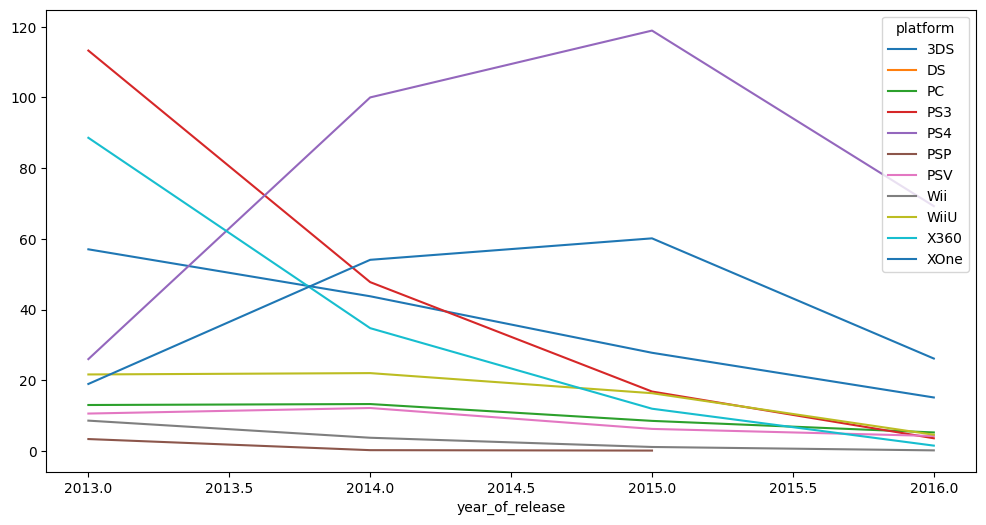

In [27]:
df_recent.groupby(['year_of_release', 'platform'])['global_sales'].sum().unstack().plot(kind='line', figsize=(12,6))

- PS 2, X 360 and PS 3 dominated the market for a long time.
- Wii and DS also sold a lot, but were already disappearing in 2016.
- PS 4 and X One, despite lower sales in total, were the main bets for the future (they were still growing).

## Building a box plot for global sales of all games

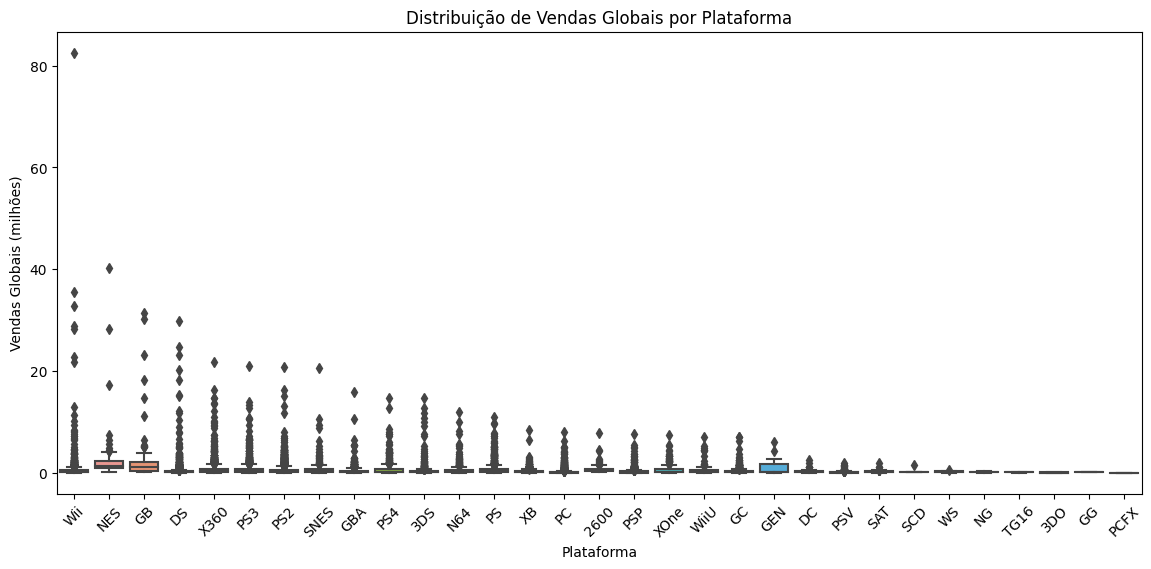

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(14, 6))
sns.boxplot(x='platform', y='global_sales', data=df)
plt.title('Distribuição de Vendas Globais por Plataforma')
plt.xlabel('Plataforma')
plt.ylabel('Vendas Globais (milhões)')
plt.xticks(rotation=45)

plt.show()

- Most platforms have very low median sales (less than 1 million).
- Some platforms, such as PS 2, PS 3, Wii, X 360, have many positive outliers — that is, several games with very high sales.
- The variation in sales between games is very large: there are games with less than 0 1 million and others with more than 20 million.

## Seeing how user and professional reviews affect sales on one of the popular platforms

In [29]:
df_ps4 = df[df['platform'] == 'PS4']

Scatterplot: user score vs global sales

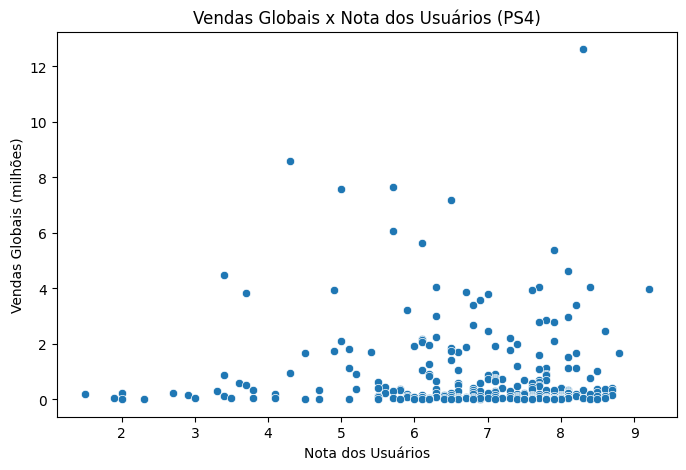

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_ps4, x='user_score', y='global_sales')
plt.title('Vendas Globais x Nota dos Usuários (PS4)')
plt.xlabel('Nota dos Usuários')
plt.ylabel('Vendas Globais (milhões)')

plt.show()

Scatterplot: critical score vs global sales

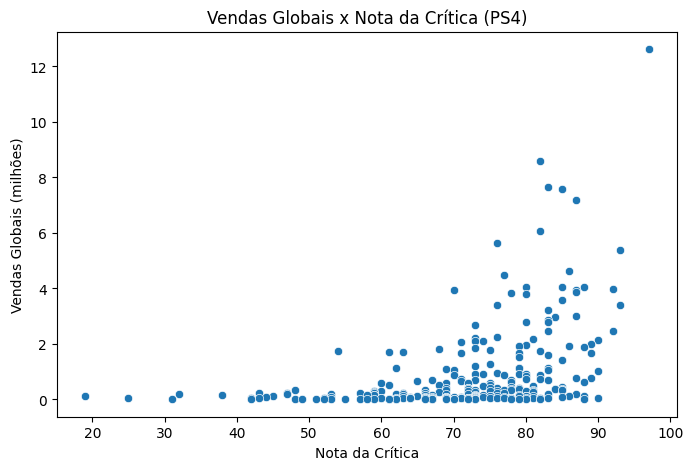

In [31]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df_ps4, x='critic_score', y='global_sales')

plt.title('Vendas Globais x Nota da Crítica (PS4)')
plt.xlabel('Nota da Crítica')
plt.ylabel('Vendas Globais (milhões)')

plt.show()

Calculating the correlation

In [32]:
print('Correlação com user_score:', df_ps4['user_score'].corr(df_ps4['global_sales']))
print('Correlação com critic_score:', df_ps4['critic_score'].corr(df_ps4['global_sales']))

Correlação com user_score: -0.031957110204556376
Correlação com critic_score: 0.40656790206178095


- User_score (- 0.03): Almost zero, that is, users scores do not have a strong relationship with sales on this platform.
- Critic_score (0.41): A moderate positive correlation, which means that the better the critics evaluation, the greater the chance of the game selling more.

## Comparing sales of the same games on other platforms

In [ ]:
# Counting how many times each game appears
jogos_multiplataforma = df['name'].value_counts()
jogos_multiplataforma = jogos_multiplataforma[jogos_multiplataforma > 1].index

In [34]:
df_multiplataforma = df[df['name'].isin(jogos_multiplataforma)]
df_multiplataforma[['name', 'platform', 'global_sales']].sort_values(by=['name', 'platform'])

,name,platform,global_sales
3357,Frozen: Olaf's Quest,3DS,0.59
3861,Frozen: Olaf's Quest,DS,0.51
9506,007: Quantum of Solace,DS,0.13
14656,007: Quantum of Solace,PC,0.02
4474,007: Quantum of Solace,PS2,0.43
...,...,...,...
2582,pro evolution soccer 2011,PSP,0.80
7148,pro evolution soccer 2011,Wii,0.22
3303,pro evolution soccer 2011,X360,0.60
8279,uDraw Studio: Instant Artist,Wii,0.17


## General distribution of games by genre.

In [ ]:
# Counting how many games there are in each genre
contagem_generos = df['genre'].value_counts()

In [ ]:
# Calculating average global sales by gender
media_vendas_genero = df.groupby('genre')['global_sales'].mean().sort_values(ascending=False)

In [ ]:
# Calculating the total sum of sales by genre
total_vendas_genero = df.groupby('genre')['global_sales'].sum().sort_values(ascending=False)

- Most profitable genres on average: Platform, Shooter, Role Playing.
- Genres with highest volume and total sales: Action, Sports.
- Genres with the least impact on sales: Strategy, Adventure.

# Creating a user profile for each region.

In [ ]:
# Main platforms by region

top5_platforms_na = df.groupby('platform')['na_sales'].sum().sort_values(ascending=False).head(5)
top5_platforms_eu = df.groupby('platform')['eu_sales'].sum().sort_values(ascending=False).head(5)
top5_platforms_jp = df.groupby('platform')['jp_sales'].sum().sort_values(ascending=False).head(5)

print(top5_platforms_na, top5_platforms_eu ,top5_platforms_jp)

platform
X360    602.47
PS2     583.84
Wii     496.90
PS3     393.49
DS      382.40
Name: na_sales, dtype: float64 platform
PS2     339.29
PS3     330.29
X360    270.76
Wii     262.21
PS      213.61
Name: eu_sales, dtype: float64 platform
DS      175.57
PS      139.82
PS2     139.20
SNES    116.55
3DS     100.67
Name: jp_sales, dtype: float64


In [ ]:
# Main genres by region

top5_genres_na = df.groupby('genre')['na_sales'].sum().sort_values(ascending=False).head(5)
top5_genres_eu = df.groupby('genre')['eu_sales'].sum().sort_values(ascending=False).head(5)
top5_genres_jp = df.groupby('genre')['jp_sales'].sum().sort_values(ascending=False).head(5)

print(top5_genres_na,top5_genres_eu, top5_genres_jp)

genre
Action      879.01
Sports      684.43
Shooter     592.24
Platform    445.50
Misc        407.27
Name: na_sales, dtype: float64 genre
Action     519.13
Sports     376.79
Shooter    317.34
Racing     236.51
Misc       212.74
Name: eu_sales, dtype: float64 genre
Role-Playing    355.41
Action          161.43
Sports          135.54
Platform        130.83
Misc            108.11
Name: jp_sales, dtype: float64


In [ ]:
# Sales by ESRB rating in each region

esrb_na = df.groupby('rating')['na_sales'].sum().sort_values(ascending=False)
esrb_eu = df.groupby('rating')['eu_sales'].sum().sort_values(ascending=False)
esrb_jp = df.groupby('rating')['jp_sales'].sum().sort_values(ascending=False)

print(esrb_na, esrb_eu, esrb_jp)

rating
E       1292.99
T        759.75
M        748.48
E10+     353.32
K-A        2.56
EC         1.53
AO         1.26
RP         0.00
Name: na_sales, dtype: float64 rating
E       710.25
M       483.97
T       427.03
E10+    188.52
AO        0.61
K-A       0.27
EC        0.11
RP        0.08
Name: eu_sales, dtype: float64 rating
E       198.11
T       151.40
M        64.24
E10+     40.20
K-A       1.46
AO        0.00
EC        0.00
RP        0.00
Name: jp_sales, dtype: float64


1. Main platforms in each region:

In North America (NA):
X 360, PS 2, Wii, PS 3 and DS are the top 5.

In Europe (EU):
PS 2, PS 3, X 360, Wii and PS lead.

In Japan (JP):
DS, PS, PS 2, SNES and 3 DS are the best sellers.

Interpretation:
Each region has different preferences: NA and EU have a lot of strength in Xbox and Play Station generation consoles, while Japan prefers portable and older consoles (DS, SNES, 3 DS).

2. Main genres in each region:

NA: Action, Sports, Shooter, Platform e Misc.

EU: Action, Sports, Shooter, Racing e Misc.

JP: Role Playing (RPG), Action, Sports, Platform e Misc.

Interpretation:
North America and Europe have similar tastes (action, sports, shooting), but Japan prefers RPGs, which are very popular there.

3. How do ESRB ratings affect sales?

The E (Everyone) classification leads in sales in all three regions, especially in North America.

Games for T (Teen) and M (Mature) also sell well, but less than E.

Ratings like AO (Adults Only) and RP (Rating Pending) have almost zero sales.

Interpretation:
Games for all ages (E) have greater acceptance and sales, especially in the US More mature games sell less, and games restricted to adults sell almost nothing.

# Testing the following hypotheses:

In [ ]:
from scipy.stats import ttest_ind

# Filtering user ratings for Xbox One and PC
scores_xone = df[(df['platform'] == 'XOne') & (df['user_score'].notna())]['user_score']
scores_pc = df[(df['platform'] == 'PC') & (df['user_score'].notna())]['user_score']

# Testingt t for Xbox One vs PC
t_stat1, p_value1 = ttest_ind(scores_xone, scores_pc, equal_var=False)

# Filtering notes for Action and Sports genres
scores_action = df[(df['genre'] == 'Action') & (df['user_score'].notna())]['user_score']
scores_sports = df[(df['genre'] == 'Sports') & (df['user_score'].notna())]['user_score']

# Testing t for Action vs Sports
t_stat2, p_value2 = ttest_ind(scores_action, scores_sports, equal_var=False)

print(f"Teste Xbox One vs PC: p-valor = {p_value1}")
print(f"Teste Action vs Sports: p-valor = {p_value2}")

Teste Xbox One vs PC: p-valor = 4.935072360183574e-06
Teste Action vs Sports: p-valor = 0.11483818791498286


How did you formulate the alternative and null hypotheses

- Null hypothesis (H 0):

The average user ratings are the same for both groups compared.

In the first test: Xbox One and PC have equal average user ratings.

In the second test: the Action and Sports genres have equal average user ratings.

- Alternative hypothesis (H 1):

The average user ratings are different between the two groups.

In the first test: Xbox One and PC have different average ratings.

In the second test: Action and Sports have different rating averages.

What level of significance did you choose to test the hypotheses, and why

- I chose a significance level of 0.05 (5%) because it is a common standard in statistical tests

# Write a general conclusion

- General Conclusion:

In this project, we analyzed sales data for electronic games considering various platforms, genres and regions.

### Main points:

- The data covers information such as game name, platform, year of release, genre, sales by region, reviews from critics and users, and ESRB rating.
- We note that the most profitable platforms vary by region. For example, Xbox 360 leads in sales in North America, while Nintendo DS is popular in Japan.
- Genres such as Action and Sports have the highest global sales, however, in some regions, genres such as Role Playing are more valued.
- Critic reviews have a moderate correlation with sales, while user reviews have little correlation
Statistical tests indicated that average user ratings differ significantly between Xbox One and PC platforms, but not between the Action and Sports genres.
- 2016 data may be incomplete, which may impact some more recent analyzes.